<a href="https://colab.research.google.com/github/tuchanski/spambase-classification/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint Report - Data Science

## Bachelor's Degree in Computer Science / PUCPR (2026-2)

**Prof. Rayson Laroca**

`Guilherme Tuchanski Rocha` - `guilherme.tuchanski@gmail.com | guilherme.tuchanski@pucpr.edu.br`

### Project Overview: Email Spam Classification

This project addresses the task of **email spam classification** using the **Spambase** dataset from the UCI Machine Learning Repository. The objective is to analyze characteristics extracted from email messages and investigate how these features differ between spam and legitimate emails.

The dataset contains numerical features related to the frequency of specific words and characters, as well as information about sequences of consecutive capital letters. These characteristics can be explored to identify patterns associated with spam messages.

During the project, the dataset will be analyzed through descriptive statistics, univariate and multivariate analyses, and data visualizations. In later stages, machine learning models will be trained and evaluated to classify emails as spam or non-spam.

#### Dataset Characteristics

* **Instances:** 4,601 records in the original dataset.
* **Features:** 57 numerical features describing word frequencies, character frequencies, and capitalization patterns.
* **Target:** The `Class` variable, where `1` represents spam and `0` represents non-spam.
* **Task:** Binary classification.
* **Source:** UCI Machine Learning Repository.

# Import the libs you need

In [1]:
# Install missing packages only; reruns work offline once dependencies are installed.
import importlib.util
import subprocess
import sys

packages = {"pandas": "pandas", "numpy": "numpy", "matplotlib": "matplotlib",
            "sklearn": "scikit-learn", "scipy": "scipy"}
missing = [package for module, package in packages.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown


# Load your data

The original dataset and its documentation are archived in `data/`. Extract the complete submission ZIP before running the notebook from that folder. In Colab, upload and extract `Equipe04.zip` first.

Source: [UCI Spambase](https://archive.ics.uci.edu/dataset/94/spambase). [Download the original archive](https://archive.ics.uci.edu/static/public/94/spambase.zip). The archive contains the original 4,601 rows; cleaning is performed below, not in the archived copy.

**Question:** Are the values valid for their definitions, and how does removing identical rows affect the sample and class balance?

**Analysis:** Check numeric types, missing and infinite values, labels, frequency ranges, uppercase consistency, and duplicate rows. Compare class proportions before and after cleaning.


In [3]:
# Read original UCI column names and data locally; no data download is needed.
data_dir = Path("data")
if not (data_dir / "spambase.data").exists():
    raise FileNotFoundError("Extract Equipe04.zip and run from the folder containing data/.")
column_names = [line.split(":", 1)[0].strip()
                for line in (data_dir / "spambase.names").read_text().splitlines()
                if line.startswith(("word_freq_", "char_freq_", "capital_run_length_"))]
assert len(column_names) == 57

df_raw = pd.read_csv(data_dir / "spambase.data", header=None,
                     names=column_names + ["Class"])
df = df_raw.copy()
df.head()


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [4]:
print(df.shape)
print(df.info())
print(df.isnull().sum().sum())

df.head()

(4601, 58)
<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [5]:
# Start from the original data so this section can be run again safely.
df = df_raw.copy()
print(f"Number of records before cleaning: {len(df)}")

Number of records before cleaning: 4601


In [6]:
# 1. Require numeric values; stop if an unexpected text value is found.
df = df.apply(pd.to_numeric, errors="raise")

# Missing or infinite values need investigation before analysis can continue.
missing_values = df.isna().sum().sum()
infinite_values = np.isinf(df.to_numpy()).sum()
print(f"Missing values: {missing_values}")
print(f"Infinite values: {infinite_values}")
assert missing_values == 0, "Investigate missing values before continuing."
assert infinite_values == 0, "Investigate infinite values before continuing."

Missing values: 0
Infinite values: 0


In [7]:
# 2. Validate labels BEFORE converting to integers (0.5 must not become 0).
assert df["Class"].isin([0, 1]).all(), "Class must contain only 0 or 1."
df["Class"] = df["Class"].astype(int)
print(f"Class values: {sorted(df['Class'].unique())}")

Class values: [np.int64(0), np.int64(1)]


In [8]:
# 3. Frequencies are percentages, so valid values range from 0 to 100.
frequency_cols = df.filter(regex=r"^(word_freq_|char_freq_)").columns
assert df[frequency_cols].ge(0).all().all(), "Negative frequency found."
assert df[frequency_cols].le(100).all().all(), "Frequency above 100 found."

# Zero frequencies mean absence; keep them and do not remove outliers blindly.
average = df["capital_run_length_average"]
longest = df["capital_run_length_longest"]
total = df["capital_run_length_total"]
assert average.ge(0).all(), "Negative capital run length found."
assert (average <= longest).all(), "Average run length exceeds the longest run."
assert (longest <= total).all(), "Longest run exceeds total capital letters."
assert ((longest % 1 == 0) & (total % 1 == 0)).all(), "Capital counts must be integers."

In [9]:
# 4. Keep one copy of each identical row to reduce repeated observations.
# This is an analysis choice: matching features do not prove emails are identical.
duplicates = df.duplicated().sum()
df = df.drop_duplicates().copy()
print(f"Duplicate rows removed: {duplicates}")

# Check for identical features with different labels; keep them for review.
feature_cols = df.columns.drop("Class").tolist()
label_counts = df.groupby(feature_cols, dropna=False)["Class"].nunique()
print(f"Feature groups with conflicting labels: {(label_counts > 1).sum()}")
# Later, keep identical feature groups in the same train/test partition.

Duplicate rows removed: 391
Feature groups with conflicting labels: 3


In [10]:
# 5. Compare class percentages to see the effect of removing duplicates.
class_balance = pd.DataFrame({
    "Before (%)": df_raw["Class"].value_counts(normalize=True) * 100,
    "After (%)": df["Class"].value_counts(normalize=True) * 100,
}).sort_index()
display(class_balance.round(2))

,Before (%),After (%)
Class,,
0,60.6,60.12
1,39.4,39.88


In [11]:
# 6. Rebuild X and y so later analysis uses the cleaned data.
X = df.drop(columns="Class").copy()
y = df["Class"].copy()

# Fit scaling or imputation only on training data during the modeling stage.
print("Data types:")
print(df.dtypes.value_counts())

Data types:
float64    55
int64       3
Name: count, dtype: int64


In [12]:
# Final summary; retain original row indices to trace records back to df_raw.
print(f"Number of records after cleaning: {len(df)}")
print(f"Number of features: {X.shape[1]}")
display(df.head())

Number of records after cleaning: 4210
Number of features: 57


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


# Statistical Description

**Question:** How large is the cleaned dataset, what kind of classification task does it support, and how balanced are its classes?

**Analysis:** Report the number and type of predictors, observation count, target labels, class counts and percentages, and majority-class accuracy reference. Compare the dimensions with the required minimum of 1,000 observations and 30 predictors.


In [13]:
features = df.drop(columns="Class")
target = df["Class"]

summary = pd.Series({
    "Number of instances": len(df),
    "Number of features": features.shape[1],
    "Feature type": "Numeric (word/character frequencies and capital run lengths)",
    "Task": "Binary classification",
    "Target variable": "Class (0 = non-spam, 1 = spam)",
    "Number of classes": target.nunique(),
}, name="Value")
display(summary.to_frame())

,Value
Number of instances,4210
Number of features,57
Feature type,Numeric (word/character frequencies and capita...
Task,Binary classification
Target variable,"Class (0 = non-spam, 1 = spam)"
Number of classes,2


In [14]:
# Show both counts and percentages to make the class balance easy to compare.
class_distribution = target.value_counts().sort_index().rename("Count").to_frame()
class_distribution["Percentage (%)"] = (class_distribution["Count"] / len(df) * 100).round(2)
class_distribution.index = class_distribution.index.map({0: "Non-spam (0)", 1: "Spam (1)"})
class_distribution.index.name = "Class"
display(class_distribution)

,Count,Percentage (%)
Class,,
Non-spam (0),2531,60.12
Spam (1),1679,39.88


In [15]:
# Use the majority class as a simple reference for later model evaluation.
majority_percentage = class_distribution["Count"].max() / len(df) * 100
print(f"Always predicting the majority class would give {majority_percentage:.2f}% accuracy.")

Always predicting the majority class would give 60.12% accuracy.


**Discussion:** The target is categorical even though it is encoded as integers: **0 means non-spam** and **1 means spam**. The 57 predictors describe word frequencies (48 features), character frequencies (6 features), and capital letter sequences (3 features).

After cleaning, the dataset contains **4,210 emails**: **2,531 non-spam (60.12%)** and **1,679 spam (39.88%)**. Non-spam is the majority class, but both classes are well represented. Accuracy should be compared with the majority-class baseline and complemented by precision, recall, and F1-score during model evaluation. These percentages describe this dataset and should not be assumed to represent all email traffic.

The cleaned data exceeds both size requirements. Validation found no missing or infinite values or invalid ranges. Removing 391 repeated rows leaves 4,210 emails; three groups with identical predictors but conflicting labels are retained. Removing duplicates is an analysis choice, and zero frequencies and valid extreme observations are preserved.


# Univariate data analysis

In this section, you should perform univariate data analysis on at least **20 variables**.

In the end, you should describe the main variables that are of your interest, and these should be accounted for in the next sections of the report.
The definition of each variable chosen should be clarified, so arbitrary selections are **not** accepted at this point.

For each variable plotted, make sure you determine the following:
1. The distribution of the data (Gaussian, binomial, exponential, etc.);
2. Skewness;
3. Kurtosis;
4. Mean, standard deviation, and what they stand for in the context of the dataset.

Ensure that each variable is **plotted correctly** based on its type. For instance, make sure scatterplots are not used for categorical data and so forth.

## Approach and variable selection

We analyze **20 numerical predictors and the target**, using the cleaned `df`. Each variable is examined separately; relationships with spam will be investigated in the multivariate section. The selection covers message content, punctuation, and capitalization, based on their meaning rather than a ranking against the target.

For `word_freq_WORD`, the value is the percentage of words matching that token. For `char_freq_CHAR`, it is the percentage of characters matching that symbol. A zero indicates absence. Capital run lengths describe consecutive uppercase letters. These definitions follow the [UCI Spambase documentation](https://archive.ics.uci.edu/dataset/94/spambase).

| Variable | Definition | Reason for inclusion | Question |
|---|---|---|---|
| `word_freq_free` | Percentage of words equal to “free” | Explore language about free offers. | Is this token absent from most emails, with a long right tail among its observed frequencies? |
| `word_freq_money` | Percentage of words equal to “money” | Explore financial language. | Is this token absent from most emails, with a long right tail among its observed frequencies? |
| `word_freq_credit` | Percentage of words equal to “credit” | Explore credit-related content. | Is this token absent from most emails, with a long right tail among its observed frequencies? |
| `word_freq_order` | Percentage of words equal to “order” | Explore purchasing language. | Is this token absent from most emails, with a long right tail among its observed frequencies? |
| `word_freq_business` | Percentage of words equal to “business” | Explore commercial or professional content. | Is this token absent from most emails, with a long right tail among its observed frequencies? |
| `word_freq_remove` | Percentage of words equal to “remove” | Explore a possible unsubscribe-related token. | Is this token absent from most emails, with a long right tail among its observed frequencies? |
| `word_freq_you` | Percentage of words equal to “you” | Measure direct address to the reader. | Is this token absent from most emails, with a long right tail among its observed frequencies? |
| `word_freq_your` | Percentage of words equal to “your” | Measure another form of reader-directed language. | Is this token absent from most emails, with a long right tail among its observed frequencies? |
| `word_freq_hp` | Percentage of words equal to “hp” | Explore vocabulary tied to the dataset's organizational context. | Is this token absent from most emails, with a long right tail among its observed frequencies? |
| `word_freq_george` | Percentage of words equal to “george” | Explore a personal name specific to this collection. | Is this token absent from most emails, with a long right tail among its observed frequencies? |
| `word_freq_meeting` | Percentage of words equal to “meeting” | Explore workplace or scheduling content. | Is this token absent from most emails, with a long right tail among its observed frequencies? |
| `word_freq_re` | Percentage of words equal to “re” | Explore a token that may occur in replies; this is not a subject-line indicator. | Is this token absent from most emails, with a long right tail among its observed frequencies? |
| `char_freq_!` | Percentage of exclamation marks | Measure emphatic punctuation. | Is this token absent from most emails, with a long right tail among its observed frequencies? |
| `char_freq_$` | Percentage of dollar signs | Explore monetary notation. | Is this token absent from most emails, with a long right tail among its observed frequencies? |
| `char_freq_#` | Percentage of hash signs | Explore numbering or formatting. | Is this token absent from most emails, with a long right tail among its observed frequencies? |
| `char_freq_(` | Percentage of opening parentheses | Explore punctuation used in explanations or formatting. | Is this token absent from most emails, with a long right tail among its observed frequencies? |
| `char_freq_;` | Percentage of semicolons | Explore another writing or formatting pattern. | Is this token absent from most emails, with a long right tail among its observed frequencies? |
| `capital_run_length_average` | Average uppercase run length in an email | Measure typical uppercase sequence length within a message. | Is the mean greater than the median, suggesting that large uppercase values pull the average upward? |
| `capital_run_length_longest` | Longest uppercase run in an email | Measure the most sustained uppercase sequence. | Is the mean greater than the median, suggesting that large uppercase values pull the average upward? |
| `capital_run_length_total` | Total uppercase letters in an email | Measure overall uppercase volume; this also depends on message length. | Is the mean greater than the median, suggesting that large uppercase values pull the average upward? |
| `Class` | 0 = non-spam, 1 = spam | Describe the target distribution for later comparisons. | Is non-spam the majority class, and what fraction of emails is spam? |

These reasons are exploratory hypotheses, not evidence that a variable identifies spam.

Each question is evaluated separately for its variable. The following group tables and plots provide the analysis, followed by individual answers and a group discussion.


In [16]:
import matplotlib.pyplot as plt

# Keep named groups so the selection is explicit and reusable in later sections.
univariate_groups = {
    "Commercial and subscription vocabulary": [
        "word_freq_free", "word_freq_money", "word_freq_credit",
        "word_freq_order", "word_freq_business", "word_freq_remove",
    ],
    "Reader and contextual vocabulary": [
        "word_freq_you", "word_freq_your", "word_freq_hp",
        "word_freq_george", "word_freq_meeting", "word_freq_re",
    ],
    "Punctuation": [
        "char_freq_!", "char_freq_$", "char_freq_#", "char_freq_(", "char_freq_;",
    ],
    "Capitalization": [
        "capital_run_length_average", "capital_run_length_longest",
        "capital_run_length_total",
    ],
}
selected_features = [column for columns in univariate_groups.values() for column in columns]
univariate_variables = selected_features + ["Class"]

# Work on a separate selection; plotting must not modify the cleaned data.
univariate_data = df[selected_features].copy()
print(f"Analyzing {len(selected_features)} predictors and Class across {len(df):,} emails.")

Analyzing 20 predictors and Class across 4,210 emails.


## How to read the statistics and plots

The tables report statistics on the **original values**. The mean is the average across emails; the sample standard deviation measures variation around that mean. For frequencies, means are percentages and standard deviations are **percentage points**. Each email receives equal weight, so a mean word frequency is not the percentage obtained by pooling every word in the dataset. Capitalization means and standard deviations are measured in letters; the mean of `capital_run_length_average` averages the per-email averages.

The median and quartiles help describe typical emails when extreme values pull the mean upward. Positive skewness indicates a longer right tail, negative skewness a longer left tail. We use **excess kurtosis**, where a Gaussian distribution has value 0; large positive values indicate strong tail/extreme-value influence relative to that reference. Neither statistic alone identifies a probability distribution.

Each histogram shows one numeric variable using 30 bins of **`log1p(value)`**, meaning the natural logarithm of one plus the value. This compresses long right tails while preserving zeros and all observations. The horizontal axis is transformed; tables and annotated statistics remain in original units. This is only a visualization choice, not a transformation of `df` or a modeling decision. Dashed lines mark the transformed locations of the original mean and median.

We describe empirical distribution shapes without fitting Gaussian or exponential models. Frequency variables can combine an exact-zero mass with positive values. The two uppercase counts are discrete; average run length and frequencies are treated as continuous. The binary target uses a bar chart.

In [17]:
# Add robust summaries and zero percentages because averages alone can hide sparsity.
univariate_stats = univariate_data.describe().T.rename(columns={
    "count": "Count", "mean": "Mean", "std": "Std. dev.",
    "min": "Min", "25%": "Q1", "50%": "Median", "75%": "Q3", "max": "Max",
})
univariate_stats["Zero (%)"] = univariate_data.eq(0).mean() * 100
univariate_stats["Skewness"] = univariate_data.skew()
# pandas reports Fisher's excess kurtosis: the Gaussian reference is zero.
univariate_stats["Excess kurtosis"] = univariate_data.kurt()

def describe_univariate_group(group_name):
    columns = univariate_groups[group_name]
    # Two narrow tables are easier to read than one table with every statistic.
    display(univariate_stats.loc[columns, [
        "Mean", "Std. dev.", "Min", "Q1", "Median", "Q3", "Max",
    ]].round(3))
    display(univariate_stats.loc[columns, [
        "Zero (%)", "Skewness", "Excess kurtosis",
    ]].round(3))

    rows = (len(columns) + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(15, 3.8 * rows), squeeze=False)
    for ax, column in zip(axes.flat, columns):
        values = univariate_data[column]
        stats = univariate_stats.loc[column]
        ax.hist(np.log1p(values), bins=30, color="#4477AA", edgecolor="white")
        ax.axvline(np.log1p(stats["Mean"]), color="#BB5566", linestyle="--", label="Mean")
        ax.axvline(np.log1p(stats["Median"]), color="#228833", linestyle=":", label="Median")
        ax.set_title(column, fontsize=10)
        unit = "frequency (%)" if "freq_" in column else "length in letters"
        ax.set_xlabel(f"log1p({unit})")
        ax.set_ylabel("Number of emails")
        ax.text(0.97, 0.75, f"Zeros: {stats['Zero (%)']:.1f}%",
                transform=ax.transAxes, ha="right", fontsize=9)
        ax.legend(fontsize=8, loc="upper right")
    for ax in axes.flat[len(columns):]:
        ax.set_visible(False)
    fig.suptitle(group_name, fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    # Answer each variable's question using the displayed statistics.
    answers = []
    for column in columns:
        stats = univariate_stats.loc[column]
        if column.startswith(("word_freq_", "char_freq_")):
            majority_absent = "Yes" if stats["Zero (%)"] > 50 else "No"
            answer = (f"{majority_absent}: absent in {stats['Zero (%)']:.1f}% of emails; "
                      f"median {stats['Median']:.3f}%. "
                      f"Mean {stats['Mean']:.3f}%, standard deviation "
                      f"{stats['Std. dev.']:.3f} percentage points.")
        else:
            answer = (f"{'Yes' if stats['Mean'] > stats['Median'] else 'No'}: "
                      f"mean {stats['Mean']:.3f} versus median {stats['Median']:.3f} letters; "
                      f"standard deviation {stats['Std. dev.']:.3f} letters.")
        shape = "right-skewed" if stats["Skewness"] > 0 else "not right-skewed"
        answers.append(f"- **{column}:** {answer} The distribution is {shape} "
                       f"(skewness {stats['Skewness']:.2f}; excess kurtosis "
                       f"{stats['Excess kurtosis']:.2f}).")
    display(Markdown("**Discussion by variable:**\n\n" + "\n".join(answers)))


## Commercial and subscription vocabulary

**Questions:** See the individual questions for these variables in the selection table above.

**Analysis:** Examine each variable's histogram and original-scale mean, standard deviation, quartiles, zero percentage, skewness, and excess kurtosis. Describe the empirical shape; no named probability distribution is assumed without a fitted model.


,Mean,Std. dev.,Min,Q1,Median,Q3,Max
word_freq_free,0.254,0.798,0.0,0.0,0.0,0.128,20.00
word_freq_money,0.091,0.432,0.0,0.0,0.0,0.000,12.50
word_freq_credit,0.085,0.506,0.0,0.0,0.0,0.000,18.18
word_freq_order,0.092,0.282,0.0,0.0,0.0,0.000,5.26
word_freq_business,0.149,0.458,0.0,0.0,0.0,0.000,7.14
word_freq_remove,0.117,0.397,0.0,0.0,0.0,0.000,7.27


,Zero (%),Skewness,Excess kurtosis
word_freq_free,72.542,9.388,157.692
word_freq_money,84.347,15.557,340.176
word_freq_credit,90.760,15.430,424.686
word_freq_order,82.850,5.284,48.011
word_freq_business,78.480,5.568,43.514
word_freq_remove,81.900,6.809,76.382


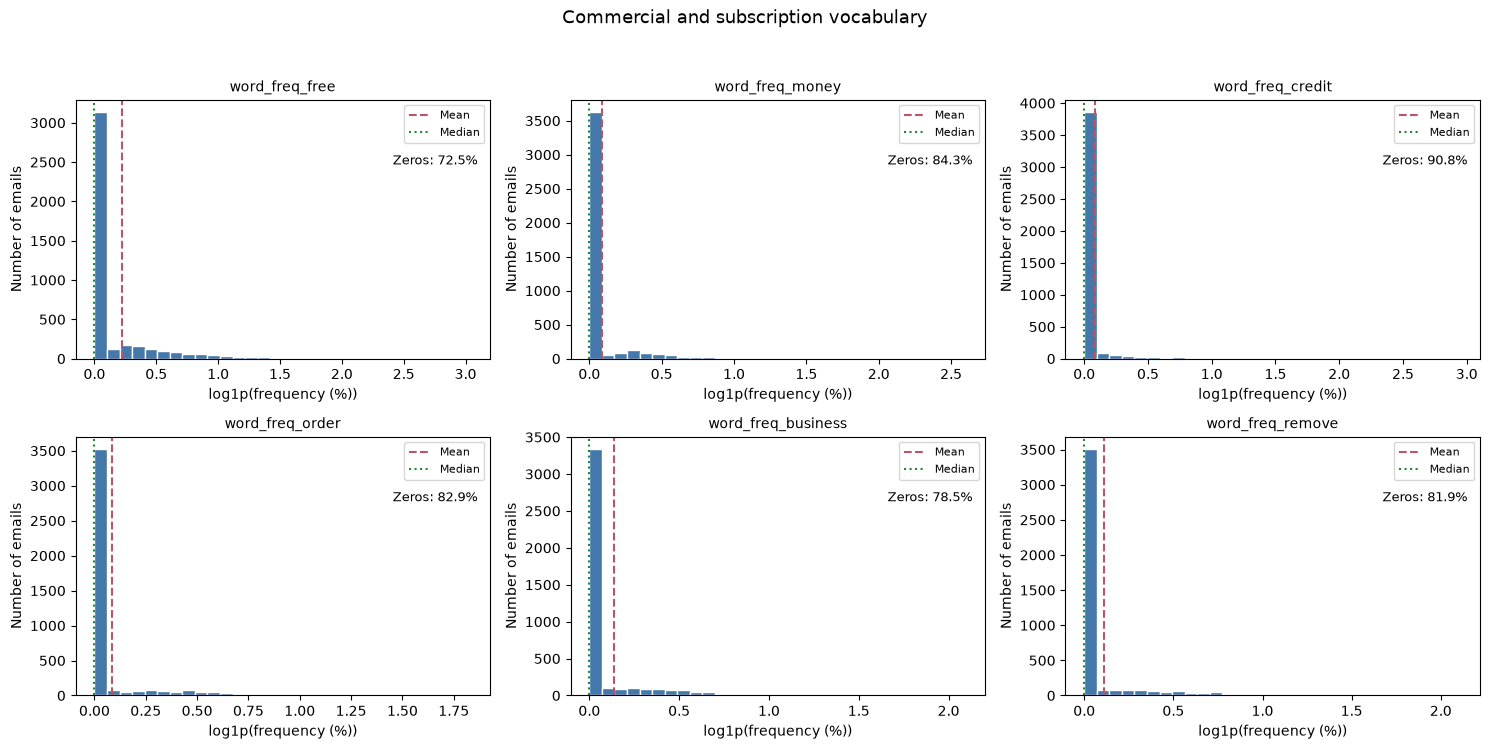

**Discussion by variable:**

- **word_freq_free:** Yes: absent in 72.5% of emails; median 0.000%. Mean 0.254%, standard deviation 0.798 percentage points. The distribution is right-skewed (skewness 9.39; excess kurtosis 157.69).
- **word_freq_money:** Yes: absent in 84.3% of emails; median 0.000%. Mean 0.091%, standard deviation 0.432 percentage points. The distribution is right-skewed (skewness 15.56; excess kurtosis 340.18).
- **word_freq_credit:** Yes: absent in 90.8% of emails; median 0.000%. Mean 0.085%, standard deviation 0.506 percentage points. The distribution is right-skewed (skewness 15.43; excess kurtosis 424.69).
- **word_freq_order:** Yes: absent in 82.9% of emails; median 0.000%. Mean 0.092%, standard deviation 0.282 percentage points. The distribution is right-skewed (skewness 5.28; excess kurtosis 48.01).
- **word_freq_business:** Yes: absent in 78.5% of emails; median 0.000%. Mean 0.149%, standard deviation 0.458 percentage points. The distribution is right-skewed (skewness 5.57; excess kurtosis 43.51).
- **word_freq_remove:** Yes: absent in 81.9% of emails; median 0.000%. Mean 0.117%, standard deviation 0.397 percentage points. The distribution is right-skewed (skewness 6.81; excess kurtosis 76.38).

In [18]:
describe_univariate_group("Commercial and subscription vocabulary")

**Discussion:** All six variables have **a large mass at zero and a long right tail**, rather than an approximately Gaussian shape. Their medians are zero, and positive skewness and high excess kurtosis show that uncommon large values strongly affect the averages. A simple continuous exponential model would also miss the exact-zero mass.

`free` has the highest mean in this group (about **0.254%**, standard deviation **0.798 percentage points**), but is absent from about **72.5%** of emails. `credit` is absent from about **90.8%**, and its excess kurtosis is especially large (about **424.7**). `money`, `order`, `business`, and `remove` show the same broad pattern of absence in most messages and occasional larger frequencies. These variables are useful candidates for later comparisons of both presence and frequency by class; their univariate distributions do not establish a spam association.

## Reader and contextual vocabulary

**Questions:** See the individual questions for these variables in the selection table above.

**Analysis:** Examine each variable's histogram and original-scale mean, standard deviation, quartiles, zero percentage, skewness, and excess kurtosis. Describe the empirical shape; no named probability distribution is assumed without a fitted model.


,Mean,Std. dev.,Min,Q1,Median,Q3,Max
word_freq_you,1.718,1.769,0.0,0.0,1.36,2.720,18.75
word_freq_your,0.810,1.149,0.0,0.0,0.29,1.280,11.11
word_freq_hp,0.574,1.677,0.0,0.0,0.00,0.098,20.83
word_freq_george,0.370,1.775,0.0,0.0,0.00,0.000,33.33
word_freq_meeting,0.142,0.794,0.0,0.0,0.00,0.000,14.28
word_freq_re,0.320,1.046,0.0,0.0,0.00,0.170,21.42


,Zero (%),Skewness,Excess kurtosis
word_freq_you,27.221,1.524,4.998
word_freq_your,45.724,2.246,8.094
word_freq_hp,74.727,5.639,43.182
word_freq_george,84.157,9.482,111.100
word_freq_meeting,92.043,9.185,108.995
word_freq_re,70.356,8.918,122.068


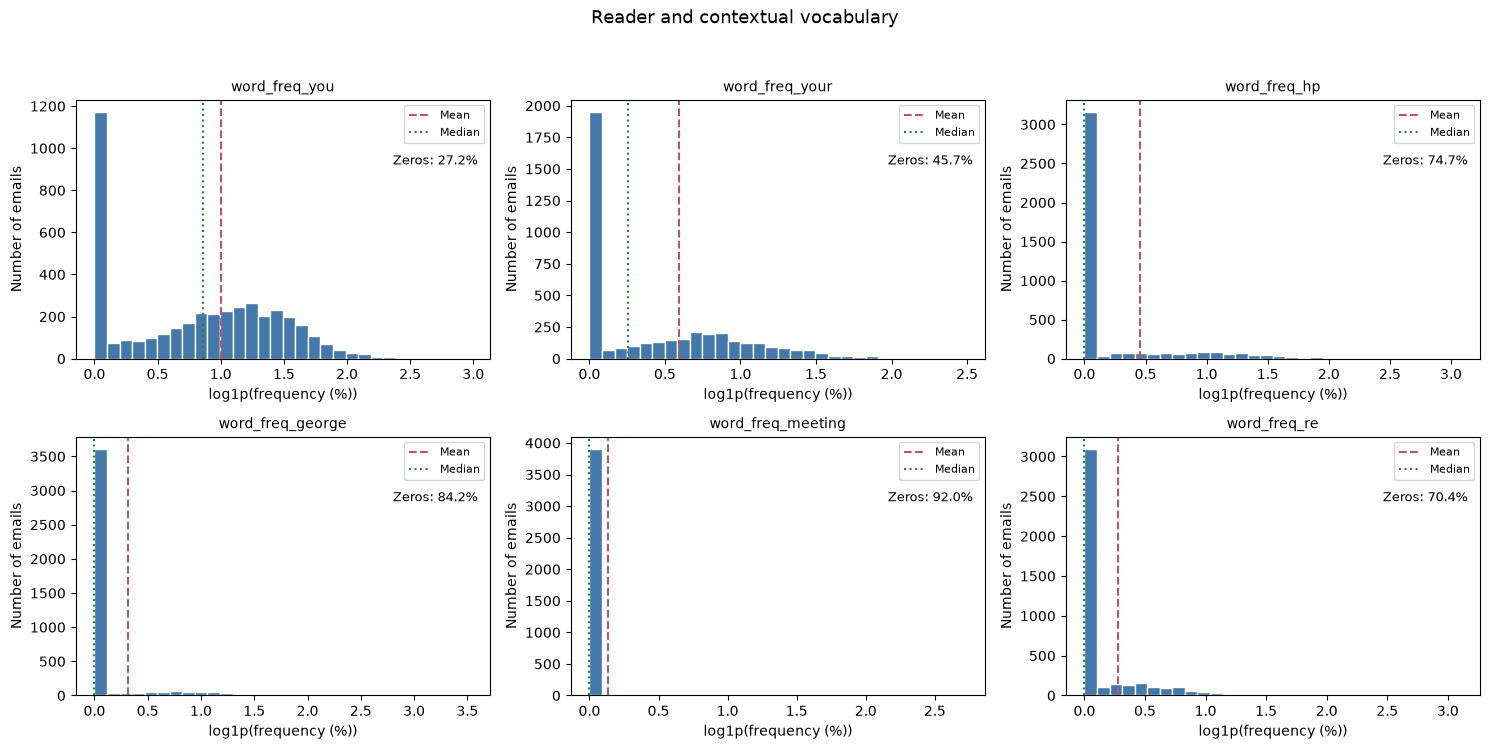

**Discussion by variable:**

- **word_freq_you:** No: absent in 27.2% of emails; median 1.360%. Mean 1.718%, standard deviation 1.769 percentage points. The distribution is right-skewed (skewness 1.52; excess kurtosis 5.00).
- **word_freq_your:** No: absent in 45.7% of emails; median 0.290%. Mean 0.810%, standard deviation 1.149 percentage points. The distribution is right-skewed (skewness 2.25; excess kurtosis 8.09).
- **word_freq_hp:** Yes: absent in 74.7% of emails; median 0.000%. Mean 0.574%, standard deviation 1.677 percentage points. The distribution is right-skewed (skewness 5.64; excess kurtosis 43.18).
- **word_freq_george:** Yes: absent in 84.2% of emails; median 0.000%. Mean 0.370%, standard deviation 1.775 percentage points. The distribution is right-skewed (skewness 9.48; excess kurtosis 111.10).
- **word_freq_meeting:** Yes: absent in 92.0% of emails; median 0.000%. Mean 0.142%, standard deviation 0.794 percentage points. The distribution is right-skewed (skewness 9.19; excess kurtosis 108.99).
- **word_freq_re:** Yes: absent in 70.4% of emails; median 0.000%. Mean 0.320%, standard deviation 1.046 percentage points. The distribution is right-skewed (skewness 8.92; excess kurtosis 122.07).

In [19]:
describe_univariate_group("Reader and contextual vocabulary")

**Discussion:** All six distributions are **right-skewed with positive excess kurtosis**. `you` and `your` are less concentrated at zero than the other words: their zero percentages are about **27.2%** and **45.7%**, and their medians are positive. `you` has a mean of about **1.718%** and a standard deviation of **1.769 percentage points**, indicating substantial variation in direct-address language across emails.

`hp`, `george`, `meeting`, and `re` each have a zero median and a sparse positive tail. For example, `meeting` is absent from about **92.0%** of emails. These four variables are not well summarized by a symmetric Gaussian shape. Their context makes them worth comparing with the target, but vocabulary tied to this particular collection may not generalize to other email sources.

## Punctuation

**Questions:** See the individual questions for these variables in the selection table above.

**Analysis:** Examine each variable's histogram and original-scale mean, standard deviation, quartiles, zero percentage, skewness, and excess kurtosis. Describe the empirical shape; no named probability distribution is assumed without a fitted model.


,Mean,Std. dev.,Min,Q1,Median,Q3,Max
char_freq_!,0.281,0.843,0.0,0.0,0.016,0.331,32.478
char_freq_$,0.076,0.240,0.0,0.0,0.000,0.053,6.003
char_freq_#,0.046,0.436,0.0,0.0,0.000,0.000,19.829
char_freq_(,0.144,0.274,0.0,0.0,0.073,0.194,9.752
char_freq_;,0.040,0.253,0.0,0.0,0.000,0.000,4.385


,Zero (%),Skewness,Excess kurtosis
char_freq_!,49.121,18.337,579.438
char_freq_$,69.169,10.609,188.463
char_freq_#,83.325,31.500,1238.321
char_freq_(,38.670,14.003,404.370
char_freq_;,82.185,13.356,200.450


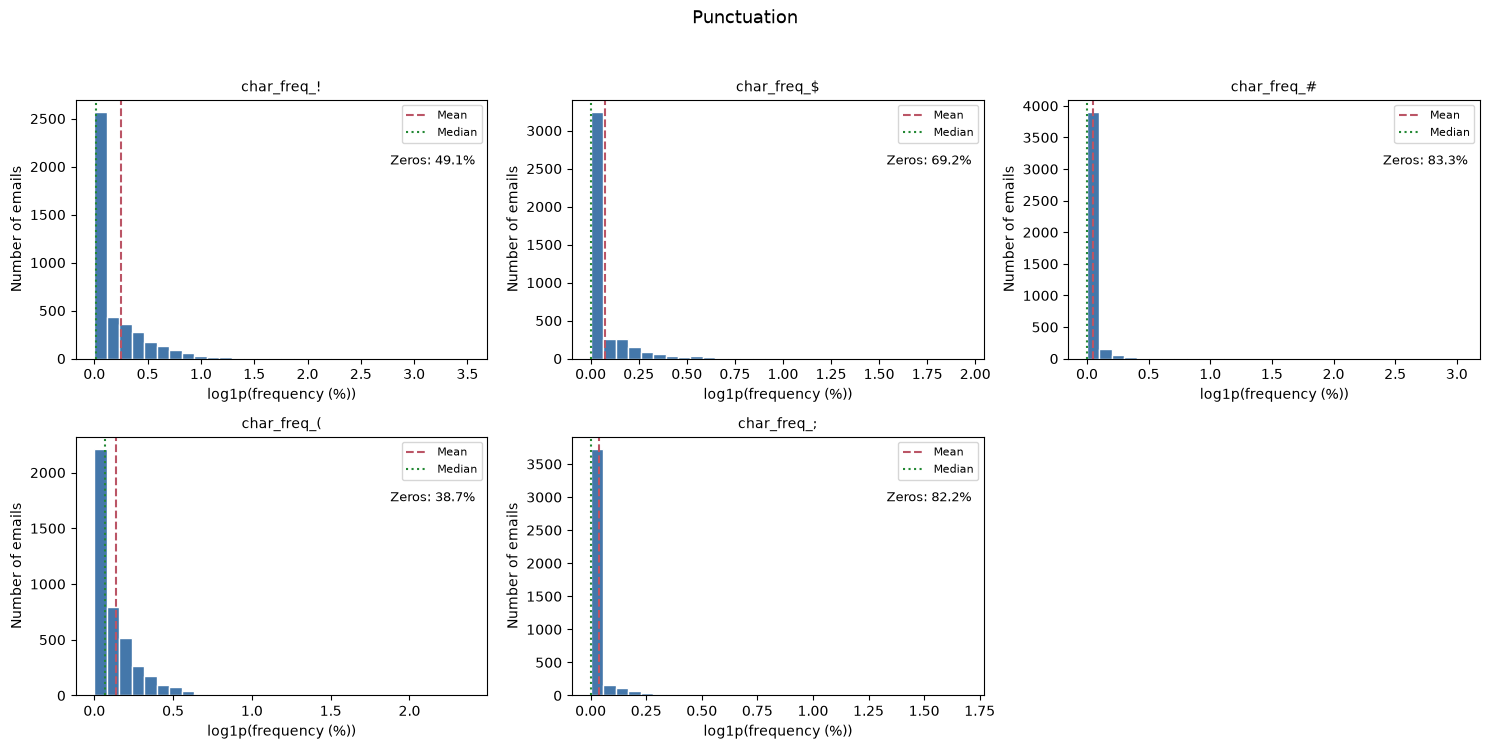

**Discussion by variable:**

- **char_freq_!:** No: absent in 49.1% of emails; median 0.016%. Mean 0.281%, standard deviation 0.843 percentage points. The distribution is right-skewed (skewness 18.34; excess kurtosis 579.44).
- **char_freq_$:** Yes: absent in 69.2% of emails; median 0.000%. Mean 0.076%, standard deviation 0.240 percentage points. The distribution is right-skewed (skewness 10.61; excess kurtosis 188.46).
- **char_freq_#:** Yes: absent in 83.3% of emails; median 0.000%. Mean 0.046%, standard deviation 0.436 percentage points. The distribution is right-skewed (skewness 31.50; excess kurtosis 1238.32).
- **char_freq_(:** No: absent in 38.7% of emails; median 0.073%. Mean 0.144%, standard deviation 0.274 percentage points. The distribution is right-skewed (skewness 14.00; excess kurtosis 404.37).
- **char_freq_;:** Yes: absent in 82.2% of emails; median 0.000%. Mean 0.040%, standard deviation 0.253 percentage points. The distribution is right-skewed (skewness 13.36; excess kurtosis 200.45).

In [20]:
describe_univariate_group("Punctuation")

**Discussion:** Each punctuation variable has **an exact-zero mass and a long right tail**, with positive skewness and high excess kurtosis. Exclamation marks and opening parentheses have positive medians; dollar signs, hash signs, and semicolons have zero medians.

`char_freq_!` averages about **0.281%** with a standard deviation of **0.843 percentage points**. Its small median (**0.016%**) shows how much larger the mean is than a typical central value. `char_freq_#` has particularly extreme skewness (about **31.5**) and excess kurtosis (about **1,238.3**), despite a mean of only **0.046%**. Rare high frequencies deserve attention, but the univariate results do not justify deleting them or assuming they are errors.

## Capitalization

**Questions:** See the individual questions for these variables in the selection table above.

**Analysis:** Examine each variable's histogram and original-scale mean, standard deviation, quartiles, zero percentage, skewness, and excess kurtosis. Describe the empirical shape; no named probability distribution is assumed without a fitted model.


,Mean,Std. dev.,Min,Q1,Median,Q3,Max
capital_run_length_average,5.384,33.147,1.0,1.628,2.297,3.707,1102.5
capital_run_length_longest,52.140,199.582,1.0,7.000,15.000,44.000,9989.0
capital_run_length_total,291.182,618.655,1.0,40.000,101.500,273.750,15841.0


,Zero (%),Skewness,Excess kurtosis
capital_run_length_average,0.0,22.761,614.400
capital_run_length_longest,0.0,31.205,1471.216
capital_run_length_total,0.0,8.802,146.108


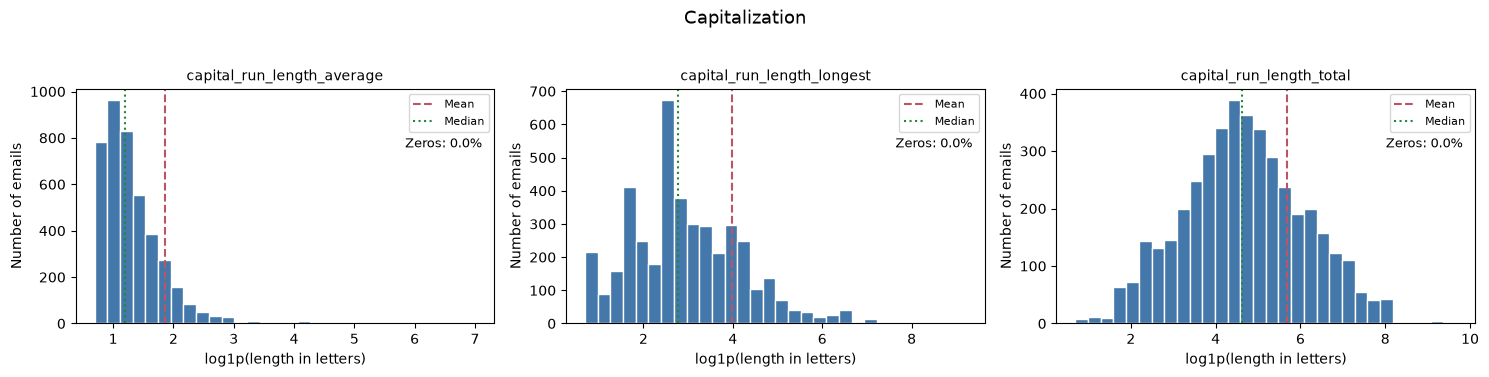

**Discussion by variable:**

- **capital_run_length_average:** Yes: mean 5.384 versus median 2.297 letters; standard deviation 33.147 letters. The distribution is right-skewed (skewness 22.76; excess kurtosis 614.40).
- **capital_run_length_longest:** Yes: mean 52.140 versus median 15.000 letters; standard deviation 199.582 letters. The distribution is right-skewed (skewness 31.21; excess kurtosis 1471.22).
- **capital_run_length_total:** Yes: mean 291.182 versus median 101.500 letters; standard deviation 618.655 letters. The distribution is right-skewed (skewness 8.80; excess kurtosis 146.11).

In [21]:
describe_univariate_group("Capitalization")

**Discussion:** All three capitalization variables are **strongly right-skewed with long upper tails** and no zeros in the cleaned dataset. Their positive skewness and very high excess kurtosis do not support an approximately Gaussian description on the original scale. The longest run and total uppercase volume are discrete counts; the average run length is continuous. A named distribution is not established here.

The per-email average run length has a mean of about **5.384 letters** and a standard deviation of **33.147 letters**, compared with a median of **2.297**. The longest run averages **52.140 letters** with a standard deviation of **199.582**, while its median is only **15** and its maximum is **9,989**. Total uppercase volume averages **291.182 letters** with a standard deviation of **618.655**, compared with a median of **101.5**. These gaps show why the median and quartiles are useful alongside the mean. Total uppercase volume can also reflect email length, which these three variables alone cannot separate from capitalization style.

## Target distribution

**Question:** Is non-spam the majority class, and what fraction of emails is spam?

**Analysis:**

`Class` is categorical, so counts are shown with a bar chart. For a single email, its 0/1 encoding can be described by a **Bernoulli distribution**, with the spam probability estimated by the observed proportion. The mean is therefore the spam fraction. The standard deviation measures the spread of the binary indicator; skewness and excess kurtosis describe its encoded distribution, not an ordered measure of email quality.

,Class
Mean (spam fraction),0.3988
Std. dev. (binary indicator),0.4897
Skewness,0.4134
Excess kurtosis,-1.8299


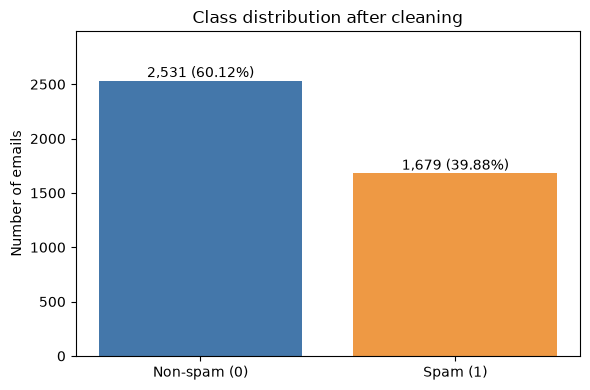

In [22]:
# Fix the category order so both labels remain explicit.
class_counts = df["Class"].value_counts().reindex([0, 1], fill_value=0)
class_percentages = class_counts / len(df) * 100
target_stats = pd.Series({
    "Mean (spam fraction)": df["Class"].mean(),
    "Std. dev. (binary indicator)": df["Class"].std(),
    "Skewness": df["Class"].skew(),
    "Excess kurtosis": df["Class"].kurt(),
}, name="Class")
display(target_stats.round(4).to_frame())

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Non-spam (0)", "Spam (1)"], class_counts, color=["#4477AA", "#EE9944"])
for bar, count, percentage in zip(bars, class_counts, class_percentages):
    ax.text(bar.get_x() + bar.get_width() / 2, count + 35,
            f"{count:,} ({percentage:.2f}%)", ha="center")
ax.set_ylim(0, class_counts.max() * 1.18)
ax.set_ylabel("Number of emails")
ax.set_title("Class distribution after cleaning")
fig.tight_layout()
plt.show()

**Discussion:** The empirical Bernoulli parameter is approximately **0.399**: about **39.88%** of the cleaned emails are spam and **60.12%** are non-spam. The binary indicator's sample standard deviation is about **0.490**. Its slight positive skewness reflects the less frequent value 1; negative excess kurtosis is consistent with a two-point distribution and is not a data-quality issue.

## Main findings and variables for the next section

The selected numeric predictors all have right-skewed distributions and positive excess kurtosis. Most selected word frequencies have zero medians, while a small number of large observations raise the means. We retain zeros and extreme values: absence is meaningful, and the earlier validation did not identify these values as invalid. No additional cleaning is performed here.

For multivariate analysis, the main candidates are **`word_freq_free`, `word_freq_money`, `word_freq_remove`, `word_freq_you`, `word_freq_your`, `word_freq_hp`, `word_freq_george`, `char_freq_!`, `char_freq_$`, and all three capitalization variables**, together with **`Class`**. They cover commercial content, reader-directed language, collection-specific vocabulary, punctuation, and uppercase usage. We can investigate how their distributions differ by class and whether related measures vary together. `char_freq_#` is also worth revisiting because of its unusually extreme tail.

The list `univariate_variables` contains every variable covered here and can be reused to keep later plots within the analyzed set. This selection is for exploration, not a final model feature set. Univariate analysis alone cannot demonstrate predictive value or relationships between variables.

# Multivariate data analysis

In this section, you should plot at least **5 multivariate visualizations**. The key here is to investigate underlying correlations and behaviors within the dataset.
Naturally, as visualizations are being created, we should end up with obvious results, yet, you should find at least **ONE** non-obvious behavior in the data.

Please follow these steps for creating your visualizations:
1. State an hypothesis. Explain why you have selected these specific variables and what you expect to discover through their relationship;
2. Determine what kind of visualization is the most suitable;
3. Report the findings and discuss whether they corroborate or not the aforementioned hypothesis.


**Hints**

In this section, make sure you go beyond naive explorations. For example, consider applying techniques such as PCA, t-SNE, or even others that we haven't covered in the lectures. The goal is to cultivate a critical mindset toward data analysis and our work.

**Important**

It is strictly prohibited to create multivariate visualizations using variables that were not included in the previous section (univariate data analysis).

## Approach

We use the cleaned `df` and only predictors already examined in the univariate section. The five analyses below compare vocabulary, joint word presence, punctuation, capitalization, and the combined feature space. **0 = non-spam; 1 = spam.**

Percentages are calculated within the group named on each plot. Tables use original units; `log1p` only compresses long tails for plotting and PCA. Spearman correlation describes monotonic relationships using ranks, which reduces the influence of extreme magnitudes but does not eliminate the effect of tied zeros. These are exploratory associations in this collection, not causal explanations or estimates of classifier performance.

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

class_names = {0: "Non-spam", 1: "Spam"}
class_colors = {0: "#4477AA", 1: "#EE9944"}

# Reuse the earlier selection; keep df unchanged throughout this section.
multivariate_data = df[univariate_variables].copy()


## 1. Vocabulary presence by class

**Question / hypothesis:** Are commercial and reader-directed words more common in spam, while contextual words are more common in non-spam? We select `free`, `money`, `remove`, `you`, `your`, `hp`, `george`, and `meeting` to compare these different kinds of content.

**Analysis:** A grouped horizontal bar chart compares the percentage of emails containing each word within each class. Presence means frequency greater than zero; this avoids having rare large frequencies dominate the comparison and accounts for unequal class sizes.

Class,Non-spam,Spam
word_freq_free,9.76,54.14
word_freq_money,2.13,36.03
word_freq_remove,1.62,42.94
word_freq_you,62.39,88.45
word_freq_your,36.86,80.52
word_freq_hp,40.22,2.74
word_freq_george,26.04,0.48
word_freq_meeting,12.49,1.13


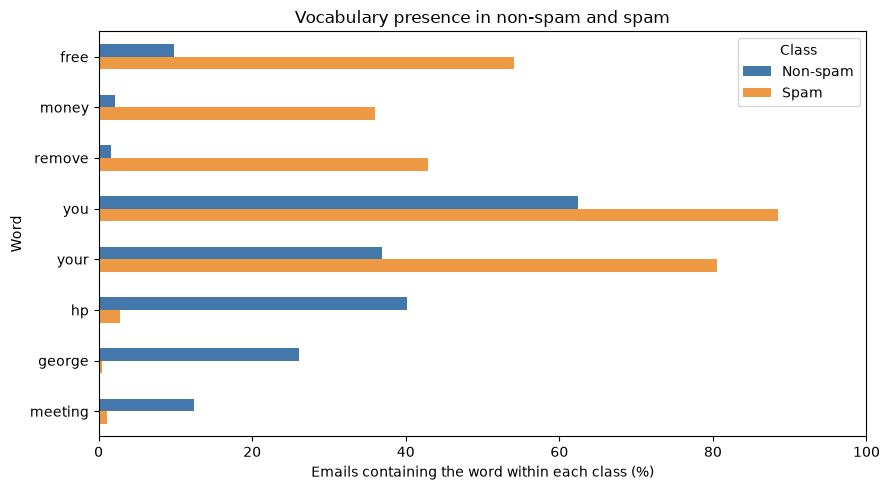

In [24]:
vocabulary = [
    "word_freq_free", "word_freq_money", "word_freq_remove",
    "word_freq_you", "word_freq_your", "word_freq_hp",
    "word_freq_george", "word_freq_meeting",
]
presence_by_class = (
    multivariate_data[vocabulary].gt(0)
    .groupby(multivariate_data["Class"]).mean().T * 100
).rename(columns=class_names)
display(presence_by_class.round(2))

ax = presence_by_class.rename(
    index=lambda name: name.replace("word_freq_", "")
).plot.barh(figsize=(9, 5), color=list(class_colors.values()))
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Emails containing the word within each class (%)")
ax.set_ylabel("Word")
ax.set_title("Vocabulary presence in non-spam and spam")
ax.legend(title="Class")
plt.tight_layout()
plt.show()


**Discussion:** The results support the hypothesis. "Free" occurs in **54.14% of spam** versus **9.76% of non-spam**, and "remove" in **42.94%** versus **1.62%**. Reader-directed words occur more often in spam too, but "you" is also present in **62.39% of non-spam**, so its presence alone is not a clear separator.

Contextual vocabulary shows the opposite pattern: "hp" appears in **40.22% of non-spam** and **2.74% of spam**, while "george" appears in **26.04%** and **0.48%**. These are strong associations in this collection, but names and organizational vocabulary may reflect how the dataset was collected and may not transfer to other email sources.

## 2. Joint presence of "free" and "money"

**Question / hypothesis:** Is the spam proportion higher when both `free` and `money` occur than when only one or neither occurs? Both words describe offers or financial content, but their joint behavior may differ from their separate associations.

**Analysis:** A bar chart shows the spam percentage in all four presence/absence combinations, with each group's sample size. The dashed line is the overall spam percentage in the cleaned dataset. Here the denominator is the combination group, whereas analysis 1 used the class.

,Emails,Spam,Spam (%)
Neither,2803,554,19.76
Money only,251,216,86.06
Free only,748,520,69.52
Both,408,389,95.34


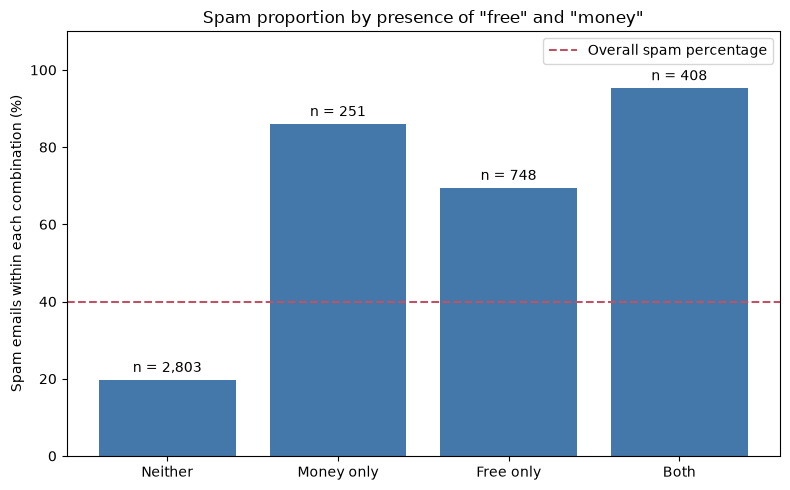

In [25]:
# Presence indicators are derived only for this comparison.
word_presence = pd.DataFrame({
    "Free present": multivariate_data["word_freq_free"].gt(0),
    "Money present": multivariate_data["word_freq_money"].gt(0),
    "Class": multivariate_data["Class"],
})
combinations = pd.MultiIndex.from_product(
    [[False, True], [False, True]], names=["Free present", "Money present"]
)
joint_summary = (
    word_presence.groupby(["Free present", "Money present"])["Class"]
    .agg(Emails="size", Spam="sum").reindex(combinations, fill_value=0)
)
joint_summary["Spam (%)"] = (
    joint_summary["Spam"] / joint_summary["Emails"].replace(0, np.nan) * 100
)
joint_summary.index = ["Neither", "Money only", "Free only", "Both"]
display(joint_summary.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(joint_summary.index, joint_summary["Spam (%)"], color="#4477AA")
for bar, count in zip(bars, joint_summary["Emails"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"n = {count:,}", ha="center")
ax.axhline(multivariate_data["Class"].mean() * 100, color="#BB5566",
           linestyle="--", label="Overall spam percentage")
ax.set_ylim(0, 110)
ax.set_ylabel("Spam emails within each combination (%)")
ax.set_title('Spam proportion by presence of "free" and "money"')
ax.legend()
fig.tight_layout()
plt.show()


**Discussion:** The hypothesis is supported descriptively: spam accounts for **95.34%** of the **408 emails containing both words**, compared with **86.06%** for money only (251 emails), **69.52%** for free only (748), and **19.76%** for neither (2,803). All three groups containing at least one of the words are above the overall **39.88%** spam proportion.

The combination provides a different view from either word alone, but this comparison does not establish a statistical interaction or a validated classification rule. Some non-spam emails contain both words, and **554 spam emails contain neither**, so the pair cannot identify all spam.

## 3. Exclamation marks and dollar signs by class

**Question / hypothesis:** Do spam emails combine more exclamation marks and dollar signs? These two punctuation variables represent emphatic writing and monetary notation, so considering them together may reveal overlap that individual distributions hide.

**Analysis:** Two scatterplots use identical axes to show `char_freq_!` against `char_freq_$`, separated by class. All observations are retained, with transparency to reduce overplotting and `log1p` on both axes to compress the tails. The table reports means and medians on the original percentage scale and a within-class Spearman correlation.

char_freq_!        char_freq_$       
                mean median        mean median
Class                                         
Non-spam       0.121  0.000       0.012  0.000
Spam           0.523  0.334       0.172  0.074

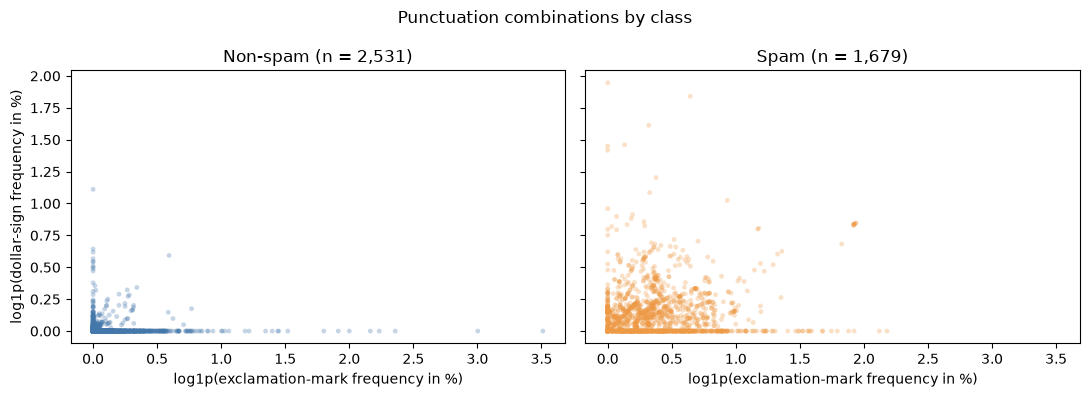

,Spearman correlation
Non-spam,0.020
Spam,0.115


In [26]:
punctuation = ["char_freq_!", "char_freq_$"]
display(multivariate_data.groupby("Class")[punctuation]
        .agg(["mean", "median"]).rename(index=class_names).round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
punctuation_correlations = {}
for ax, (label, name) in zip(axes, class_names.items()):
    group = multivariate_data.loc[multivariate_data["Class"].eq(label)]
    punctuation_correlations[name] = group[punctuation].corr(method="spearman").iloc[0, 1]
    ax.scatter(np.log1p(group[punctuation[0]]), np.log1p(group[punctuation[1]]),
               s=12, alpha=0.3, color=class_colors[label], edgecolors="none")
    ax.set_title(f"{name} (n = {len(group):,})")
    ax.set_xlabel("log1p(exclamation-mark frequency in %)")
axes[0].set_ylabel("log1p(dollar-sign frequency in %)")
fig.suptitle("Punctuation combinations by class")
fig.tight_layout()
plt.show()

display(pd.Series(punctuation_correlations, name="Spearman correlation")
        .round(3).to_frame())


**Discussion:** The higher frequencies in spam support the hypothesis at the group level. The spam medians are **0.334%** for exclamation marks and **0.074%** for dollar signs; both non-spam medians are zero. Spam also has higher means, while the plots show overlap and emails on the axes where one symbol is absent.

The two symbols are not interchangeable indicators: their within-class correlations and scattered point patterns do not imply that they always occur together. Points can overlap exactly, especially at zero, so visible point density should not be read as an exact count. Neither punctuation pattern alone establishes whether an individual email is spam.

## 4. Capitalization relationships within each class

**Question / hypothesis:** Do average uppercase run length, longest uppercase run, and total uppercase letters move together, and are these relationships similar within spam and non-spam? They describe related but different aspects of capitalization; a correlation across all emails may partly reflect differences between the classes.

**Analysis:** Three Spearman correlation heatmaps compare all emails, non-spam, and spam using the same color scale. A table of class medians provides context in original units. Comparing pooled and within-class relationships lets us investigate behavior hidden by a single overall correlation.

,capital_run_length_average,capital_run_length_longest,capital_run_length_total
Class,,,
Non-spam,1.909,11.0,63.0
Spam,3.564,38.0,191.0


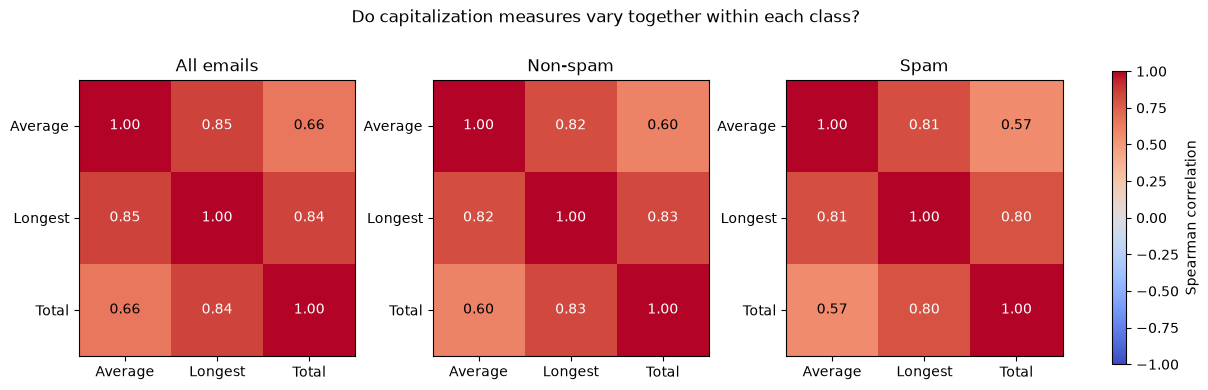

In [27]:
capitalization = univariate_groups["Capitalization"]
display(multivariate_data.groupby("Class")[capitalization].median()
        .rename(index=class_names).round(3))

capitalization_groups = {
    "All emails": multivariate_data,
    "Non-spam": multivariate_data.loc[multivariate_data["Class"].eq(0)],
    "Spam": multivariate_data.loc[multivariate_data["Class"].eq(1)],
}
capitalization_correlations = {}
fig, axes = plt.subplots(1, 3, figsize=(12, 4), layout="constrained")
for ax, (name, group) in zip(axes, capitalization_groups.items()):
    correlation = group[capitalization].corr(method="spearman")
    capitalization_correlations[name] = correlation
    heatmap = ax.imshow(correlation, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(3), ["Average", "Longest", "Total"])
    ax.set_yticks(range(3), ["Average", "Longest", "Total"])
    ax.set_title(name)
    for row in range(3):
        for column in range(3):
            value = correlation.iloc[row, column]
            ax.text(column, row, f"{value:.2f}", ha="center", va="center",
                    color="white" if abs(value) > 0.7 else "black")
fig.colorbar(heatmap, ax=axes, label="Spearman correlation", shrink=0.8)
fig.suptitle("Do capitalization measures vary together within each class?")
plt.show()


**Discussion — non-obvious finding:** All three capitalization measures are positively related, but their relationships are **weaker within each class than in the pooled data**. For example, average run length and total uppercase letters have a Spearman correlation of **0.656 overall**, compared with **0.604 in non-spam** and **0.569 in spam**. Average and longest run lengths similarly fall from **0.852 overall** to **0.815** and **0.808**.

This supports the expectation that capitalization measures move together, but not that the pooled strength describes each class equally well. The difference is consistent with class composition contributing to the overall association; it is not a reversal or proof of causation. Longest run and total uppercase letters remain strongly related within both classes (**0.829** and **0.800**), yet average run length and total volume capture different aspects of a message. Total uppercase letters can also reflect message length, which is not controlled for here.

## 5. Combined feature patterns with PCA

**Question / hypothesis:** Do the 20 previously analyzed predictors reveal a visible difference between spam and non-spam when summarized together? PCA provides a simple view of combined variation that pairwise comparisons cannot show.

**Analysis:** We apply `log1p` to reduce skewness, standardize each predictor to zero mean and unit variance, and use principal component analysis (PCA) to project the data onto two axes. Standardization prevents capitalization counts from dominating frequency variables just because of their units. **Class is excluded from PCA** and is used only to separate the plotted groups. Both panels have the same axes.

PCA finds directions of greatest variation, not directions chosen to separate spam. Axis labels report the proportion of transformed, standardized variance retained, and the table lists the six largest absolute feature coefficients for each component. These coefficients describe the component directions; they are not classifier feature importances. Scaling and PCA are fitted to the whole dataset only for exploration; any future model must fit its transformations on training data.

Variance retained by PC1 and PC2: 30.17%


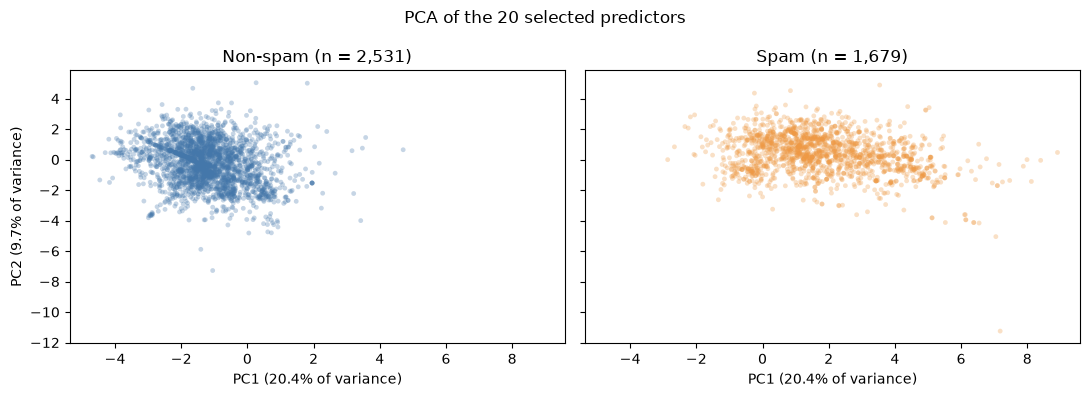

,PC1
capital_run_length_longest,0.403
capital_run_length_total,0.352
capital_run_length_average,0.350
word_freq_your,0.287
char_freq_$,0.260
word_freq_order,0.242


,PC2
word_freq_you,0.422
word_freq_hp,-0.386
capital_run_length_total,-0.347
char_freq_(,-0.302
capital_run_length_longest,-0.295
capital_run_length_average,-0.268


In [28]:
# Transform a separate array; do not change df or the original features.
pca_input = StandardScaler().fit_transform(
    np.log1p(multivariate_data[selected_features])
)
pca = PCA(n_components=2, svd_solver="full")
pca_scores = pca.fit_transform(pca_input)
explained_variance = pca.explained_variance_ratio_ * 100
print(f"Variance retained by PC1 and PC2: {explained_variance.sum():.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
for ax, (label, name) in zip(axes, class_names.items()):
    mask = multivariate_data["Class"].eq(label).to_numpy()
    ax.scatter(pca_scores[mask, 0], pca_scores[mask, 1],
               s=12, alpha=0.3, color=class_colors[label], edgecolors="none")
    ax.set_title(f"{name} (n = {mask.sum():,})")
    ax.set_xlabel(f"PC1 ({explained_variance[0]:.1f}% of variance)")
axes[0].set_ylabel(f"PC2 ({explained_variance[1]:.1f}% of variance)")
fig.suptitle("PCA of the 20 selected predictors")
fig.tight_layout()
plt.show()

pca_coefficients = pd.DataFrame(
    pca.components_.T, index=selected_features, columns=["PC1", "PC2"]
)
for component in pca_coefficients:
    strongest = pca_coefficients[component].abs().nlargest(6).index
    display(pca_coefficients.loc[strongest, [component]].round(3))


**Discussion:** PC1 explains **20.44%** and PC2 **9.72%**, retaining only **30.17%** of the variance in the transformed, standardized predictors. Spam tends toward higher PC1 scores, while non-spam tends toward lower scores, but the two groups occupy overlapping regions. This partially supports the hypothesis of a combined class-related pattern, not complete separation.

The largest PC1 coefficients include all three capitalization measures, "your", dollar signs, and "order". PC2 emphasizes another contrast involving "you", "hp", uppercase volume, and parentheses. Component signs are arbitrary; relative directions and magnitudes are what matter.

About **69.83%** of the transformed variance is outside this two-dimensional view, and explained variance is not classification accuracy. These plots motivate evaluating combinations of features later; they do not demonstrate generalization to unseen emails.

# Final Plots (Effective Data Visualization)

In this section, you need to **enhance 3 multivariate visualizations** that were presented in the previous section of the report.
The goal is to enhance these visualizations so that they can be effectively presented to an audience unfamiliar with the dataset or with data analysis.
**Therefore, make sure that their size, colors, textures, and other visual elements are appropriate and convey the intended information to the audience.**

For your final plots, make sure you follow these steps:
1. Present the plot;
2. Provide a description of the visualization, highlighting the key findings that can be drawn from it.


**Hint**: take a look at the checklist based on Evergreen’s work to ensure your visualizations meet the best practices for clarity and impact.

These three figures refine multivariate analyses 1, 2, and 4 for a general audience. They reuse the same summaries, replace technical column names with plain language, and show values directly. Color is supplemented by marker shapes or text labels. All figures use the **4,210 cleaned emails**; percentages describe this collection, not all email traffic.

**Questions:** How does word presence differ by class? How does the spam proportion differ across word combinations? Are capitalization correlations stronger overall than within each class?

**Analysis:** Replot the previously calculated summaries with direct labels and consistent scales. Each figure is followed by its discussion.


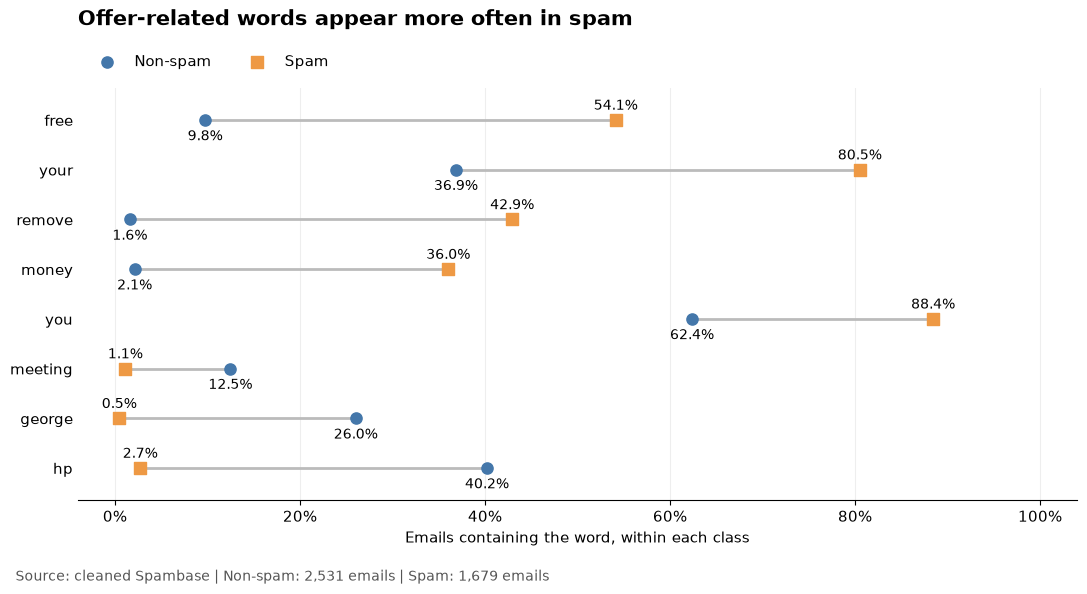

In [29]:
# Sort by the difference between classes so the contrast is easy to follow.
final_vocabulary = presence_by_class.copy()
word_order = (final_vocabulary["Spam"] - final_vocabulary["Non-spam"]).sort_values().index
final_vocabulary = final_vocabulary.loc[word_order]
positions = np.arange(len(final_vocabulary))

with plt.rc_context({"font.size": 11}):
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.hlines(positions, final_vocabulary["Non-spam"], final_vocabulary["Spam"],
              color="#BBBBBB", linewidth=2)
    for name, color, marker, offset in [
        ("Non-spam", class_colors[0], "o", -12),
        ("Spam", class_colors[1], "s", 10),
    ]:
        values = final_vocabulary[name]
        ax.scatter(values, positions, color=color, marker=marker, s=65,
                   label=name, zorder=3)
        for value, position in zip(values, positions):
            ax.annotate(f"{value:.1f}%", (value, position),
                        xytext=(0, offset), textcoords="offset points",
                        ha="center", va="center", fontsize=10)
    ax.set_yticks(positions, final_vocabulary.index.str.replace("word_freq_", "", regex=False))
    ax.set_xticks(np.arange(0, 101, 20), [f"{value}%" for value in range(0, 101, 20)])
    ax.set_xlim(-4, 104)
    ax.set_ylim(-0.65, len(final_vocabulary) - 0.35)
    ax.set_xlabel("Emails containing the word, within each class")
    ax.set_title("Offer-related words appear more often in spam",
                 loc="left", fontsize=15, fontweight="bold", pad=45)
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), ncol=2, frameon=False)
    ax.grid(axis="x", color="#EEEEEE")
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0)
    fig.text(0.02, 0.02, "Source: cleaned Spambase | Non-spam: 2,531 emails | Spam: 1,679 emails",
             fontsize=10, color="#555555")
    fig.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


**Discussion - what the figure shows:** Each row compares how often a word appears in spam and non-spam. A longer connecting line means a larger difference between the classes, not a change over time. Squares represent spam and circles represent non-spam; the labels give the percentage within each class.

"Free" appears in **54.1% of spam** but only **9.8% of non-spam**. "Remove" also has a large difference, while "you" is common in both classes. The reverse pattern for "hp" and "george" shows that collection-specific vocabulary can be informative too, although it may not generalize to other email sources. The sorted rows, short word labels, and direct percentages make the comparison easier to read than the earlier grouped bars.

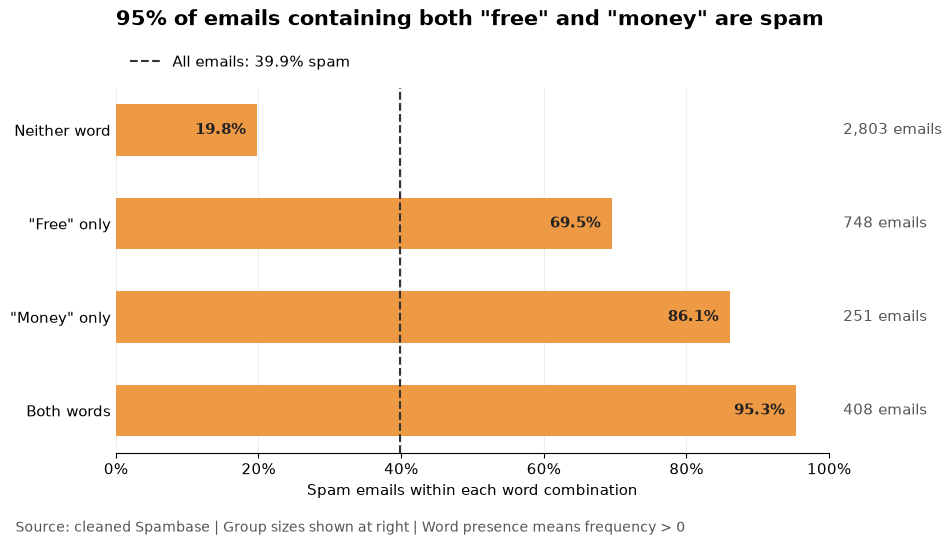

In [30]:
# Use the same four groups and keep the percentage axis between 0 and 100.
final_combinations = joint_summary.loc[["Neither", "Free only", "Money only", "Both"]]
combination_labels = ['Neither word', '"Free" only', '"Money" only', 'Both words']
overall_spam = multivariate_data["Class"].mean() * 100

with plt.rc_context({"font.size": 11}):
    fig, ax = plt.subplots(figsize=(11, 5.5))
    bars = ax.barh(combination_labels, final_combinations["Spam (%)"],
                   color=class_colors[1], height=0.55)
    for bar, rate, count in zip(bars, final_combinations["Spam (%)"],
                                final_combinations["Emails"]):
        ax.text(bar.get_width() - 1.5, bar.get_y() + bar.get_height() / 2,
                f"{rate:.1f}%", ha="right", va="center",
                fontweight="bold", color="#222222")
        ax.text(1.02, bar.get_y() + bar.get_height() / 2,
                f"{count:,} emails", transform=ax.get_yaxis_transform(),
                va="center", color="#555555")
    ax.axvline(overall_spam, color="#333333", linestyle="--", linewidth=1.5,
               label=f"All emails: {overall_spam:.1f}% spam")
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xticks(range(0, 101, 20), [f"{value}%" for value in range(0, 101, 20)])
    ax.set_xlabel("Spam emails within each word combination")
    ax.set_title('95% of emails containing both "free" and "money" are spam',
                 loc="left", fontsize=15, fontweight="bold", pad=45)
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), frameon=False)
    ax.grid(axis="x", color="#EEEEEE")
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0)
    fig.text(0.02, 0.02, "Source: cleaned Spambase | Group sizes shown at right | Word presence means frequency > 0",
             fontsize=10, color="#555555")
    fig.tight_layout(rect=[0, 0.05, 0.88, 1])
    plt.show()


**Discussion - what the figure shows:** Each bar gives the spam percentage among emails with that word combination. The dashed line marks the **39.9%** spam proportion across all cleaned emails. Group sizes are shown separately because the groups differ considerably in size.

The spam proportion rises from **19.8% when neither word appears** to **95.3% when both appear**. This is an association in the dataset, not a prediction accuracy: **554 spam emails contain neither word**, and some non-spam emails contain both. The horizontal layout, direct percentages, visible group sizes, and fixed 0-100% scale make the denominator and comparison clearer than the exploratory chart.

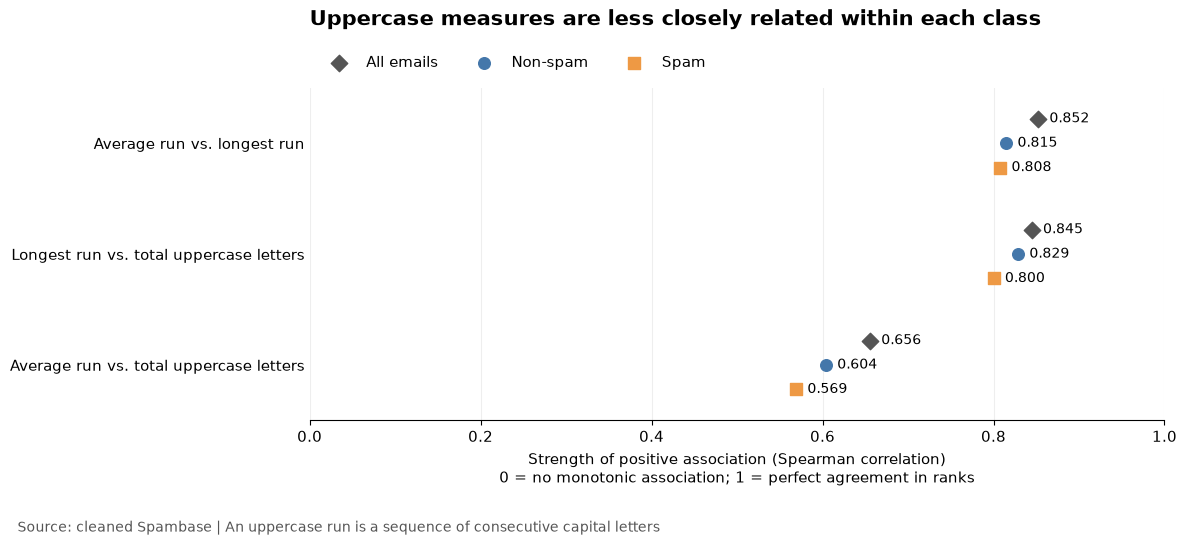

In [31]:
# Show each distinct pair once; omit the repeated cells and self-correlations.
capitalization_pairs = [
    ("capital_run_length_average", "capital_run_length_longest", "Average run vs. longest run"),
    ("capital_run_length_longest", "capital_run_length_total", "Longest run vs. total uppercase letters"),
    ("capital_run_length_average", "capital_run_length_total", "Average run vs. total uppercase letters"),
]
positions = np.arange(len(capitalization_pairs))

with plt.rc_context({"font.size": 11}):
    fig, ax = plt.subplots(figsize=(12, 5.5))
    for name, color, marker, offset in [
        ("All emails", "#555555", "D", -0.22),
        ("Non-spam", class_colors[0], "o", 0),
        ("Spam", class_colors[1], "s", 0.22),
    ]:
        values = [capitalization_correlations[name].loc[first, second]
                  for first, second, _ in capitalization_pairs]
        rows = positions + offset
        ax.scatter(values, rows, color=color, marker=marker, s=70, label=name, zorder=3)
        for value, row in zip(values, rows):
            ax.annotate(f"{value:.3f}", (value, row), xytext=(8, 0),
                        textcoords="offset points", va="center", fontsize=10)
    ax.set_yticks(positions, [label for _, _, label in capitalization_pairs])
    ax.set_ylim(len(capitalization_pairs) - 0.5, -0.5)
    ax.set_xlim(0, 1)
    ax.set_xticks(np.arange(0, 1.01, 0.2))
    ax.set_xlabel("Strength of positive association (Spearman correlation)\n"
                  "0 = no monotonic association; 1 = perfect agreement in ranks")
    ax.set_title("Uppercase measures are less closely related within each class",
                 loc="left", fontsize=15, fontweight="bold", pad=45)
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), ncol=3, frameon=False)
    ax.grid(axis="x", color="#EEEEEE")
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0)
    fig.text(0.02, 0.02, "Source: cleaned Spambase | An uppercase run is a sequence of consecutive capital letters",
             fontsize=10, color="#555555")
    fig.tight_layout(rect=[0, 0.07, 1, 1])
    plt.show()


**Discussion - what the figure shows:** A point farther right indicates that the two uppercase measures tend to increase together more consistently. All correlations shown are positive, so the horizontal axis uses 0 to 1; Spearman correlation can also be negative. Colors and marker shapes distinguish all emails, non-spam, and spam.

For every pair, the pooled correlation is higher than either within-class correlation. The clearest difference is average run length versus total uppercase letters: **0.656 overall**, **0.604 in non-spam**, and **0.569 in spam**. The direction stays positive; the finding is a difference in strength, not a reversal or evidence of causation. Class composition may contribute to the pooled relationship.

Compared with the earlier heatmaps, this chart removes repeated pairs and self-correlations, labels the measures in plain language, and places all three estimates for each pair together. Total uppercase letters can still reflect message length as well as capitalization style.

# Digest

In this section, you should briefly summarize the main findings of your project. Additionally, provide a critical reflection on your work and the effort invested throughout the module. Highlight the aspects you believe were handled successfully, as well as those that, in hindsight, you would approach differently.

While this digest must contain at least 2,500 characters, it is intended solely for self-reflection purposes and will not be considered in the formal evaluation of your work.

At this stage, the project provides an exploratory view of email spam using the Spambase dataset. It began with 4,601 emails and 57 numerical predictors describing word frequencies, punctuation, and uppercase letters. Validation found no missing or infinite values, and removing 391 identical rows left 4,210 observations. Of these, 39.88% are spam and 60.12% are non-spam. This balance matters because always choosing non-spam would already achieve 60.12% accuracy. A future classifier needs to be evaluated against that reference and with measures that distinguish missed spam from legitimate emails incorrectly flagged as spam.

The univariate analysis showed why averages alone are not enough to describe these features. The 20 selected predictors are right-skewed, and many word frequencies have a median of zero. A small number of large values can raise the mean substantially. Reporting medians, quartiles, zero percentages, and dispersion alongside the mean made the results more informative. Using log1p in the histograms made long tails easier to see while retaining zeros and all observations. Keeping original-scale statistics separate from transformed plots was a useful decision because the numerical interpretation remained clear.

The multivariate analysis connected these individual patterns to the target and to each other. Commercial words such as "free", "money", and "remove" occur more often in spam, while "hp" and "george" occur more often in non-spam. The joint comparison was especially useful: 95.34% of emails containing both "free" and "money" are spam, compared with 19.76% of emails containing neither. However, 554 spam emails contain neither word, so this pattern is not a complete classification rule. Punctuation also differs between the classes, but overlapping values make it clear that no single visual pattern identifies every message.

A less obvious result was that capitalization measures correlate more strongly across all emails than within either class. For average uppercase run length and total uppercase letters, the correlation falls from 0.656 overall to 0.604 in non-spam and 0.569 in spam. This comparison shows the value of checking subgroups before interpreting a pooled relationship. PCA offered a broader view of the 20 selected predictors after log1p and standardization. Its first two components retain only 30.17% of the transformed variance and show overlapping class patterns. The projection is useful for exploration, but it is neither a full summary of the data nor evidence of predictive accuracy.

The strongest parts of the work are the explicit validation checks, the reasons given for selecting variables, and the connection between questions, plots, and discussions. The final figures also improve communication by replacing technical variable names, stating the percentage denominators, and labeling values directly. Much of the work at this stage involves checking what a statistic actually means and choosing a display that makes comparisons fair. Reusing the earlier summaries keeps the presentation consistent with the analysis and avoids unnecessary code.

There are also decisions I would revisit. Removing identical rows is reasonable for reducing repetition, but matching extracted features does not prove that two original emails were duplicates. A later sensitivity comparison with and without deduplication would help assess this choice. Three groups with identical predictors and conflicting labels remain, so they should stay together when constructing train/test partitions. Collection-specific words may reflect the source of the messages rather than general spam behavior. The checkpoint now archives the original dataset and records dependency versions. I would establish these practices at the beginning of a future project rather than during submission preparation.

The next stage should turn these exploratory observations into a clearly defined modeling experiment. Transformations must be fitted on training data, and the validation design must account for identical predictor groups. Model comparisons should consider precision, recall, and F1-score alongside accuracy, with attention to the cost of flagging legitimate mail. Since the full dataset has already informed the exploration, that influence should be acknowledged when interpreting later evaluation results. The current work establishes useful questions and candidate patterns; it does not yet establish how well a model will generalize.

# Checkpoint Submission *(**Ignore this component in the final submission**)*

The checkpoint package is **`Equipe04.zip`**, containing the executed notebook, its PDF export, the original dataset and documentation, the README, and dependency versions. Extract the complete archive before running the notebook.

The statistical description, 20 predictor analyses plus the target, five multivariate analyses, three final figures, and Digest are complete. Model development, validation, the manuscript, and slides belong to the post-checkpoint stage.

Upload `Equipe04.zip` to Canvas before the course deadline. The archive is prepared locally; uploading it remains the student's responsibility.


# Machine Learning (**post-checkpoint!**)

In this section, you must create at least **3 machine learning models** for the task at hand. Depending on the problem's nature, you must select from classification, regression, or clustering models.
It is also important that you:
* Select **an appropriate validation protocol**, providing a rationale for why it is appropriate for this specific task;
* Choose **a suitable set of evaluation metrics**, providing an explanation for each and describing how it contributes to evaluating the model's performance in the context of this specific task.

In [32]:
# Model training and evaluation are intentionally deferred until after the checkpoint.


# Final Steps (Submission)


1. Run all cells in the notebook and make sure every cell is executed successfully, with all outputs visible;
2. Save this report as a Jupyter Notebook (`.ipynb`);
3. Export a copy of the report as a PDF file (`.pdf`), ensuring that all code cells are executed and their outputs are visible in the exported document. If the generated PDF has formatting issues, include it in the submission anyway;
4. Copy the dataset (if smaller than 10 MB);
5. Compress all the files (the Jupyter Notebook, PDF, and dataset) into a single ZIP archive (`EquipeXX.zip`);
6. Upload the ZIP file to Canvas.